## 1. Data Loading

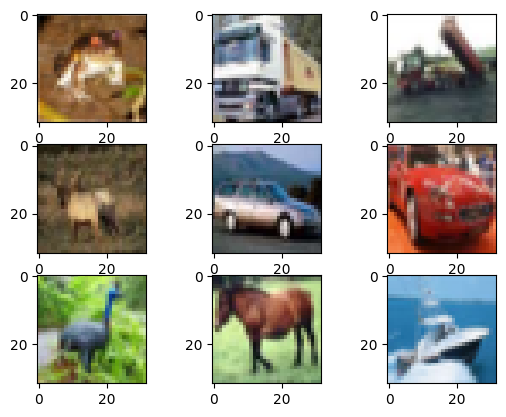

In [4]:
# Load and Plot the Data
from keras.datasets.cifar10 import load_data
from matplotlib import pyplot as plt
import numpy as np

(trainX, trainy), (testX, testy) = load_data()

for i in range(9):
    plt.subplot(330 + 1 + i)
    plt.imshow(trainX[i])
plt.show()

## 2. Building a Descriminator Model

In [5]:
from keras.models import Sequential 
from keras.optimizers import Adam
from keras.layers import Dense, Conv2D, Flatten, Dropout, LeakyReLU
from keras.utils import plot_model


In [6]:
# Create a standalone Discriminator
def define_discriminator(in_shape=(32, 32, 3)):
    model = Sequential()
    # Normal
    model.add(Conv2D(64, (3, 3), padding='same', input_shape=in_shape))
    model.add(LeakyReLU(alpha=0.2))
    #downsample
    model.add(Conv2D(128, (3, 3), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    #downsample
    model.add(Conv2D(128, (3, 3), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    #downsample
    model.add(Conv2D(256, (3, 3), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # Classifier
    model.add(Flatten())
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    # Compile Model
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model


In [7]:
model = define_discriminator()

# Show the model summary
model.summary()

# Plot the model architecture
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='discriminator_plot.png', show_shapes=True, show_layer_names=True)


/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         4,097 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,497 (1.99 MB)

 Trainable params: 522,497 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [8]:
from keras.datasets.cifar10 import load_data


In [9]:
def load_real_samples():
    (trainX,_ ), (_, _) = load_data()
    X = trainX.astype('float32')
    X = (X-127.5) /127.5
    return X

In [10]:
X = load_real_samples()
X.shape

(50000, 32, 32, 3)

In [11]:
def generate_real_samples(dataset, n_samples):
    ix = np.random.randint(0, dataset.shape[0], n_samples)
    X = dataset[ix]
    y = np.ones((n_samples, 1))
    return X, y 

In [12]:
def generate_fake_samples(n_samples):
    X = np.random.rand(32*32*3*n_samples)
    X = -1 + X * 2
    X = X.reshape((n_samples, 32, 32, 3))
    y = np.zeros((n_samples, 1))
    return X, y

In [13]:
import numpy as np
X, y = generate_real_samples(X, 64)
print(X.shape)
print(y.shape)
y[:10]


(64, 32, 32, 3)
(64, 1)


array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [14]:
X, y = generate_fake_samples(64)
print(X.shape)
print(y.shape)
y[:10]

(64, 32, 32, 3)
(64, 1)


array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9999236457885616..0.999380106795132].


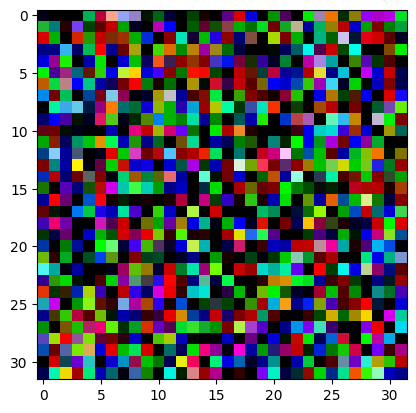

In [15]:
import matplotlib.pyplot as plt
plt.imshow(X[0])

In [16]:
# train Descriminator
def train_descriminator(model, dataset, n_iter=20, n_batch=120):
    half_batch = int(n_batch/2)

    for i in range(n_iter):
        X_real, y_real = generate_real_samples(dataset, half_batch)
        # get randomly selected 'real' samples
        _, real_acc = model.train_on_batch(X_real, y_real)
        # generate 'fake' examples
        X_fake, y_fake = generate_fake_samples(half_batch)
        #update discriminator on fake scenarios
        _, fake_acc = model.train_on_batch(X_fake, y_fake)
        # Summarize performance
        print('>%d real=%.0f%% fake=%.0f%%' % (i+1, real_acc * 100, fake_acc*100))

In [17]:
model = define_discriminator()
dataset = load_real_samples()
train_descriminator(model, dataset)

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


>1 real=45% fake=22%
>2 real=48% fake=38%
>3 real=50% fake=44%
>4 real=51% fake=49%
>5 real=54% fake=54%
>6 real=58% fake=61%
>7 real=64% fake=67%
>8 real=68% fake=70%
>9 real=72% fake=73%
>10 real=74% fake=76%
>11 real=77% fake=78%
>12 real=79% fake=79%
>13 real=80% fake=81%
>14 real=82% fake=82%
>15 real=83% fake=84%
>16 real=84% fake=85%
>17 real=85% fake=85%
>18 real=86% fake=86%
>19 real=87% fake=87%
>20 real=87% fake=88%


## 3. Building Generator

In [18]:
from keras.models import Sequential
from keras.layers import Dense, Reshape, Conv2D, Conv2DTranspose, LeakyReLU
from keras.utils import plot_model

In [19]:
def define_Generator(latent_dim):
    model = Sequential()
    n_nodes = 256 * 4 * 4
    model.add(Dense(n_nodes, input_dim= latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Reshape((4, 4, 256))) 
    # Upsample to 8x8
    model.add(Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # Upsample 16x16
    model.add(Conv2DTranspose(128, (4, 4), strides=(2,2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # Upsample 32x32
    model.add(Conv2DTranspose(128, (4, 4), strides=(2,2), padding='same'))
    model.add(LeakyReLU(alpha=0.2))
    # Output Layer
    model.add(Conv2D(3, (3, 3), activation='tanh', padding='same'))
    return model


In [20]:
latent_dim = 100
model = define_Generator(latent_dim)
model.summary()

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 4096)           │       413,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 8, 8, 128)      │       524,416 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 16, 16, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 32, 32, 128)    │       262,272 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 3)      │         3,459 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,466,115 (5.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
def generate_latent_points(latent_dim, n_samples):
    x_input = np.random.randn(latent_dim * n_samples)
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input 

In [22]:
def generate_fake_samples(g_model, latent_dim, n_samples):
    x_input = generate_latent_points(latent_dim, n_samples)
    X = g_model.predict(x_input)
    y = np.zeros((n_samples, 1))
    return X, y

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


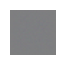

In [23]:
latent_dim = 100

model = define_Generator(latent_dim)
n_samples = 49
X, _ = generate_fake_samples(model, latent_dim, n_samples)
X = (X + 1) /2.0

for i in range(n_samples):
    plt.subplot(7, 7, 1+1)
    plt.axis('off')
    plt.imshow(X[i])
plt.show()

In [24]:
X.shape

(49, 32, 32, 3)

## 4. Defining GAN Model

In [25]:
def define_gan(g_model, d_model):
    d_model.trainable = False 
    model = Sequential()
    model.add(g_model)
    model.add(d_model)
    opt = Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt)
    return model

In [26]:
latent_dim = 100
d_model = define_discriminator()
g_model = define_Generator(latent_dim)
gan_model = define_gan(g_model, d_model)
gan_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 32, 32, 3)      │     1,466,115 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 1)              │       522,497 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,988,612 (7.59 MB)

 Trainable params: 1,466,115 (5.59 MB)

 Non-trainable params: 522,497 (1.99 MB)

In [27]:
def train(g_model, gan_model, dataset, latent_dim, n_epochs=5, n_batches=128):
    bat_per_epo = int(dataset.shape[0] /n_batches)
    half_batch = int(n_batches/2)
    for i in range(n_epochs):
        for j in range(bat_per_epo):
            X_real, y_real = generate_real_samples(dataset, half_batch)
            d_loss1, _ = d_model.train_on_batch(X_real, y_real)
            X_fake, y_fake = generate_fake_samples(g_model, latent_dim,half_batch)
            d_loss2, _ = d_model.train_on_batch(X_fake, y_fake)
            X_gan = generate_latent_points(latent_dim, n_batches)
            y_gan = np.ones((n_batches, 1))
            g_loss = gan_model.train_on_batch(X_gan, y_gan)
            print('>%d, %d/%d, d1=%.3f, d2=%.3f g=%.3f' % (i+1, j+1, bat_per_epo, d_loss1, d_loss2, g_loss))
        if (i+1) % 10 ==0:
            summarize_performance(i, g_model,d_model, dataset, latent_dim)

In [28]:
def summarize_performance(epoch, g_model, d_model, dataset, latent_dim, n_samples=150):
    X_real, y_real = generate_real_samples(dataset, n_samples)
    _, acc_real = d_model.evaluate(X_real, y_real, verbose=0)
    x_fake, y_fake = generate_fake_samples(g_model, latent_dim, n_samples)
    _, acc_fake = d_model.evaluate(x_fake, y_fake, verbose=0)
    print('>Accuracy real: %.0f%%, fake: %.0f%%' % (acc_real*100, acc_fake*100))

## 6. Train the Model

In [29]:
train(g_model, gan_model, dataset, latent_dim)

/Users/orbinsunny/.pyenv/versions/3.12.3/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
>1, 1/390, d1=0.691, d2=0.693 g=0.692
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
>1, 2/390, d1=0.692, d2=0.693 g=0.692
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
>1, 3/390, d1=0.693, d2=0.694 g=0.691
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
>1, 4/390, d1=0.694, d2=0.694 g=0.690
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
>1, 5/390, d1=0.695, d2=0.696 g=0.689
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
>1, 6/390, d1=0.695, d2=0.697 g=0.687
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
>1, 7/390, d1=0.696, d2=0.698 g=0.685
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
>1, 8/390, d1=0.697, d2=0.699 g=0.682
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
>1, 9/390, d1=0.699, d2=0.701 g=0.678
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
>1, 10/390, d1=0.701, d2=0.704 g=0.674
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
>1, 11/390, d1=0.703, d2=0.706 g=0.668
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
>1, 12/390, d1=0.706, d2=0.710 g=0.662
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
>1, 13/390, d1=0.709, d2=0.713 g=0.656
2/2 ━━━━

In [32]:
from keras.models import load_model 
from numpy.random import randn
from matplotlib import pyplot 

def generate_latent_points(latent_dim, n_samples):
    x_input = randn(latent_dim * n_samples)
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input 

def create_plot(examples, n):
    for i in range(n*n):
        pyplot.subplot(n, n, 1+i)
        pyplot.axis('off')
        pyplot.imshow(examples[i, : , :])
    pyplot.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


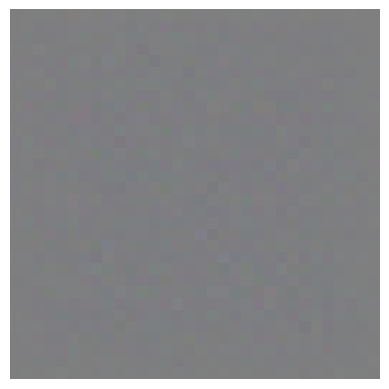

100

In [33]:
latent_points = generate_latent_points(100, 100)

X = model.predict(latent_points)
X=(X+1)/ 2.0
create_plot(X, 1)

X.shape[0]

### 1. Using GAN for Data Augmentation

In [35]:
# Generate synthetic images for augmentation
def generate_synthetic_images(generator, latent_dim, n_samples=5000):
    latent_points = np.random.randn(n_samples, latent_dim)
    synthetic_images = generator.predict(latent_points, verbose=1)
    synthetic_images = (synthetic_images + 1) / 2.0  # Rescale from [-1,1] to [0,1]
    return synthetic_images

# Example: Generate 5000 images
n_augment = 5000
synthetic_imgs = generate_synthetic_images(g_model, latent_dim, n_augment)


157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step


### 2. Label Smoothing

In [36]:
# Replace y_real and y_fake in discriminator training with soft labels
def generate_real_samples_soft(dataset, n_samples):
    ix = np.random.randint(0, dataset.shape[0], n_samples)
    X = dataset[ix]
    y = np.random.uniform(0.8, 1.0, size=(n_samples, 1))  # soft real
    return X, y

def generate_fake_samples_soft(generator, latent_dim, n_samples):
    x_input = np.random.randn(n_samples, latent_dim)
    X = generator.predict(x_input, verbose=0)
    y = np.random.uniform(0.0, 0.2, size=(n_samples, 1))  # soft fake
    return X, y
